In [34]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt

## Load Data
### Base Path

In [35]:
base_path = "../data/Sample_Game_1/"


### Load Events

In [36]:
events = pd.read_csv(base_path + "Sample_Game_1_RawEventsData.csv")
events.head()

,Team,Type,Subtype,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y
0,Away,SET PIECE,KICK OFF,1,1,0.04,0,0.00,Player19,NaN,NaN,NaN,NaN,NaN
1,Away,PASS,NaN,1,1,0.04,3,0.12,Player19,Player21,0.45,0.39,0.55,0.43
2,Away,PASS,NaN,1,3,0.12,17,0.68,Player21,Player15,0.55,0.43,0.58,0.21
3,Away,PASS,NaN,1,45,1.80,61,2.44,Player15,Player19,0.55,0.19,0.45,0.31
4,Away,PASS,NaN,1,77,3.08,96,3.84,Player19,Player21,0.45,0.32,0.49,0.47


### Load Tracking (Home)

In [37]:
tracking_home = pd.read_csv(
    base_path + "Sample_Game_1_RawTrackingData_Home_Team.csv"
)

tracking_home.head()

C:\Users\30697\AppData\Local\Temp\ipykernel_26900\1918793147.py:1: DtypeWarning: Columns (0,1,2,3,5,7,9,11,13,15,17,19,21,23,25,27,29,31) have mixed types. Specify dtype option on import or set low_memory=False.
  tracking_home = pd.read_csv(


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Home,Unnamed: 4,Home.1,Unnamed: 6,Home.2,Unnamed: 8,Home.3,...,Home.10,Unnamed: 24,Home.11,Unnamed: 26,Home.12,Unnamed: 28,Home.13,Unnamed: 30,Unnamed: 31,Unnamed: 32
0,NaN,NaN,NaN,11,NaN,1,NaN,2,NaN,3,...,10,NaN,12,NaN,13,NaN,14,NaN,NaN,NaN
1,Period,Frame,Time [s],Player11,NaN,Player1,NaN,Player2,NaN,Player3,...,Player10,NaN,Player12,NaN,Player13,NaN,Player14,NaN,Ball,NaN
2,1,1,0.04,0.00082,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.45472,0.38709
3,1,2,0.08,0.00096,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.49645,0.40656
4,1,3,0.12,0.00114,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.53716,0.42556


### Load Tracking (Away)

In [38]:
tracking_away = pd.read_csv(
    base_path + "Sample_Game_1_RawTrackingData_Away_Team.csv"
)

tracking_away.head()

C:\Users\30697\AppData\Local\Temp\ipykernel_26900\3652936359.py:1: DtypeWarning: Columns (0,1,2,3,5,7,9,11,13,15,17,19,21,23,25,27,29,31) have mixed types. Specify dtype option on import or set low_memory=False.
  tracking_away = pd.read_csv(


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Away,Unnamed: 4,Away.1,Unnamed: 6,Away.2,Unnamed: 8,Away.3,...,Away.10,Unnamed: 24,Away.11,Unnamed: 26,Away.12,Unnamed: 28,Away.13,Unnamed: 30,Away.14,Unnamed: 32
0,NaN,NaN,NaN,25,NaN,15,NaN,16,NaN,17,...,24,NaN,26,NaN,27,NaN,28,NaN,NaN,NaN
1,Period,Frame,Time [s],Player25,NaN,Player15,NaN,Player16,NaN,Player17,...,Player24,NaN,Player26,NaN,Player27,NaN,Player28,NaN,Ball,NaN
2,1,1,0.04,0.90509,0.47462,0.58393,0.20794,0.67658,0.4671,0.6731,...,0.37833,0.27383,NaN,NaN,NaN,NaN,NaN,NaN,0.45472,0.38709
3,1,2,0.08,0.90494,0.47462,0.58393,0.20794,0.67658,0.4671,0.6731,...,0.37833,0.27383,NaN,NaN,NaN,NaN,NaN,NaN,0.49645,0.40656
4,1,3,0.12,0.90434,0.47463,0.58393,0.20794,0.67658,0.4671,0.6731,...,0.37833,0.27383,NaN,NaN,NaN,NaN,NaN,NaN,0.53716,0.42556


## Data Familiarization

### Shape of each dataset

In [39]:
print("Events shape:", events.shape)
print("Home tracking shape:", tracking_home.shape)
print("Away tracking shape:", tracking_away.shape)

Events shape: (1745, 14)
Home tracking shape: (145008, 33)
Away tracking shape: (145008, 33)


### Events
#### Columns & summary table

In [40]:
events.columns

Index(['Team', 'Type', 'Subtype', 'Period', 'Start Frame', 'Start Time [s]',
       'End Frame', 'End Time [s]', 'From', 'To', 'Start X', 'Start Y',
       'End X', 'End Y'],
      dtype='object')

In [41]:
events.info()
events.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1745 entries, 0 to 1744
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Team            1745 non-null   object 
 1   Type            1745 non-null   object 
 2   Subtype         792 non-null    object 
 3   Period          1745 non-null   int64  
 4   Start Frame     1745 non-null   int64  
 5   Start Time [s]  1745 non-null   float64
 6   End Frame       1745 non-null   int64  
 7   End Time [s]    1745 non-null   float64
 8   From            1745 non-null   object 
 9   To              799 non-null    object 
 10  Start X         1664 non-null   float64
 11  Start Y         1664 non-null   float64
 12  End X           1109 non-null   float64
 13  End Y           1109 non-null   float64
dtypes: float64(6), int64(3), object(5)
memory usage: 191.0+ KB


,Team,Type,Subtype,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y
count,1745,1745,792,1745.000000,1745.000000,1745.000000,1745.000000,1745.000000,1745,799,1664.000000,1664.000000,1109.000000,1109.000000
unique,2,9,51,NaN,NaN,NaN,NaN,NaN,28,28,NaN,NaN,NaN,NaN
top,Home,PASS,INTERCEPTION,NaN,NaN,NaN,NaN,NaN,Player19,Player21,NaN,NaN,NaN,NaN
freq,917,799,290,NaN,NaN,NaN,NaN,NaN,103,69,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,1.488825,70503.382235,2820.135289,70526.925501,2821.077020,NaN,NaN,0.527139,0.502524,0.524454,0.503201
std,NaN,NaN,NaN,0.500018,41925.812208,1677.032488,41925.545286,1677.021811,NaN,NaN,0.243625,0.283635,0.242372,0.299590
min,NaN,NaN,NaN,1.000000,1.000000,0.040000,0.000000,0.000000,NaN,NaN,0.000000,-0.020000,-0.050000,-0.040000
25%,NaN,NaN,NaN,1.000000,32338.000000,1293.520000,32338.000000,1293.520000,NaN,NaN,0.360000,0.270000,0.350000,0.250000
50%,NaN,NaN,NaN,1.000000,68920.000000,2756.800000,68945.000000,2757.800000,NaN,NaN,0.530000,0.490000,0.530000,0.490000
75%,NaN,NaN,NaN,2.000000,107787.000000,4311.480000,107802.000000,4312.080000,NaN,NaN,0.702500,0.752500,0.690000,0.780000


#### Basic Info

The events dataset contains 1,745 annotated match events across two teams and two match periods.
Passes dominate the event distribution (~X%), which aligns with expected football match dynamics.
The presence of 51 unique subtypes suggests fine-grained event categorization (e.g., interceptions, clearances, etc.).
Missing values in spatial columns (Start X/Y, End X/Y) indicate that not all events are spatially defined (e.g., fouls, offsides), which will require conditional handling during spatial analysis.

#### Frames Analysis

The relationship between frame index and time usually is:

$$
\text{Time (seconds)} = \frac{\text{Frame}}{25}
$$

Equivalently:

$$
\text{Frame} = 25 \times \text{Time (seconds)}
$$

In [42]:
# Check frame theory for start and end times
events_frames=events[['Start Frame', 'End Frame','Start Time [s]','End Time [s]']].copy()
# Calculate time deriving from frame number (assuming 25 fps)
events_frames['Computed_Time_from_Frame_Start'] = events_frames['Start Frame'] / 25
events_frames['Computed_Time_from_Frame_End'] = events_frames['End Frame'] / 25

# Difference between computed time and actual start time
events_frames['Start_Time_Diff'] = (
    events_frames['Computed_Time_from_Frame_Start'] - events_frames['Start Time [s]']
)
events_frames['End_Time_Diff'] = (
    events_frames['Computed_Time_from_Frame_End'] - events_frames['End Time [s]']
)

# Max absolute difference

print("Max absolute difference:",
      events_frames['Start_Time_Diff'].abs().max()) # Should be close to zero if frame theory holds
print("Max absolute difference (End Time):",events_frames['End_Time_Diff'].abs().max())

events_frames[['Start Frame', 'Start Time [s]','End Frame', 'End Time [s]',
        'Computed_Time_from_Frame_Start', 'Computed_Time_from_Frame_End', 'Start_Time_Diff', 'End_Time_Diff']].head()

Max absolute difference: 0.0
Max absolute difference (End Time): 0.0


,Start Frame,Start Time [s],End Frame,End Time [s],Computed_Time_from_Frame_Start,Computed_Time_from_Frame_End,Start_Time_Diff,End_Time_Diff
0,1,0.04,0,0.00,0.04,0.00,0.0,0.0
1,1,0.04,3,0.12,0.04,0.12,0.0,0.0
2,3,0.12,17,0.68,0.12,0.68,0.0,0.0
3,45,1.80,61,2.44,1.80,2.44,0.0,0.0
4,77,3.08,96,3.84,3.08,3.84,0.0,0.0


### Univariate Categorical Distribution Analysis



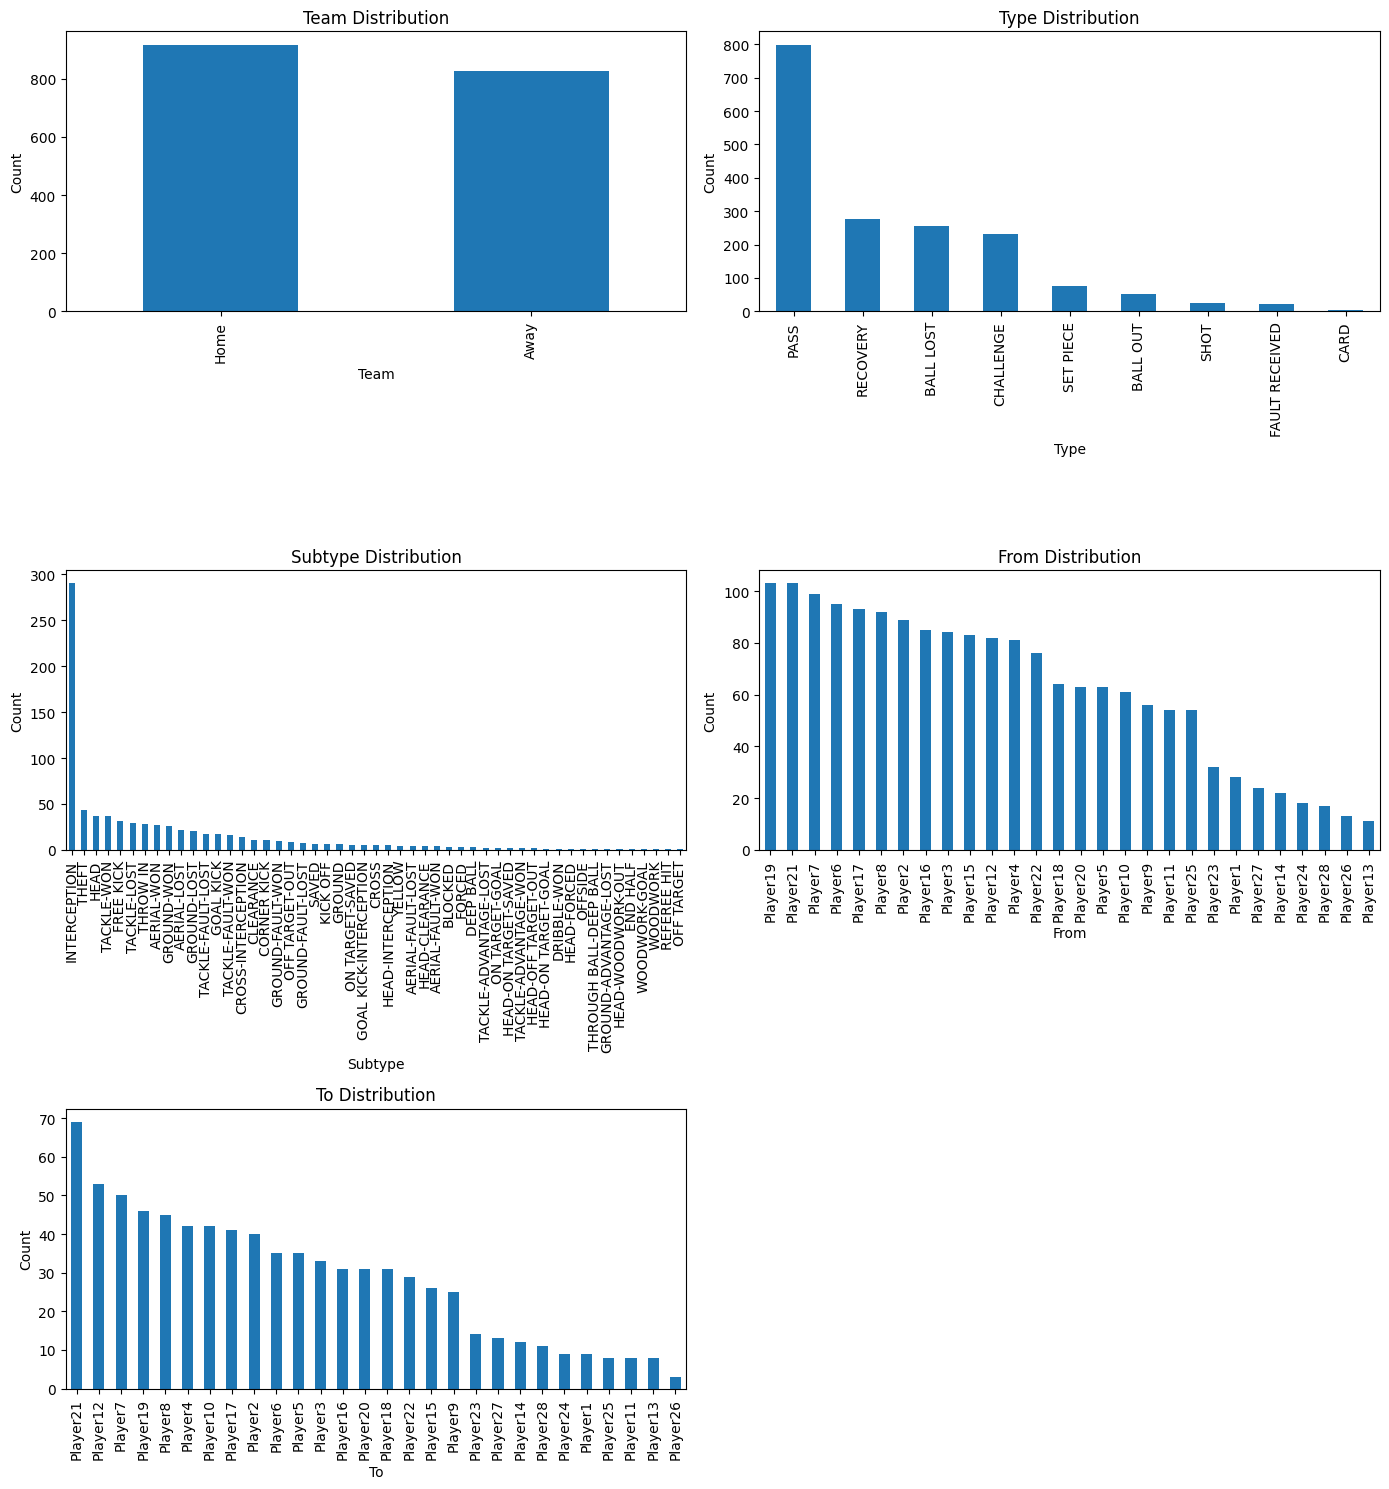

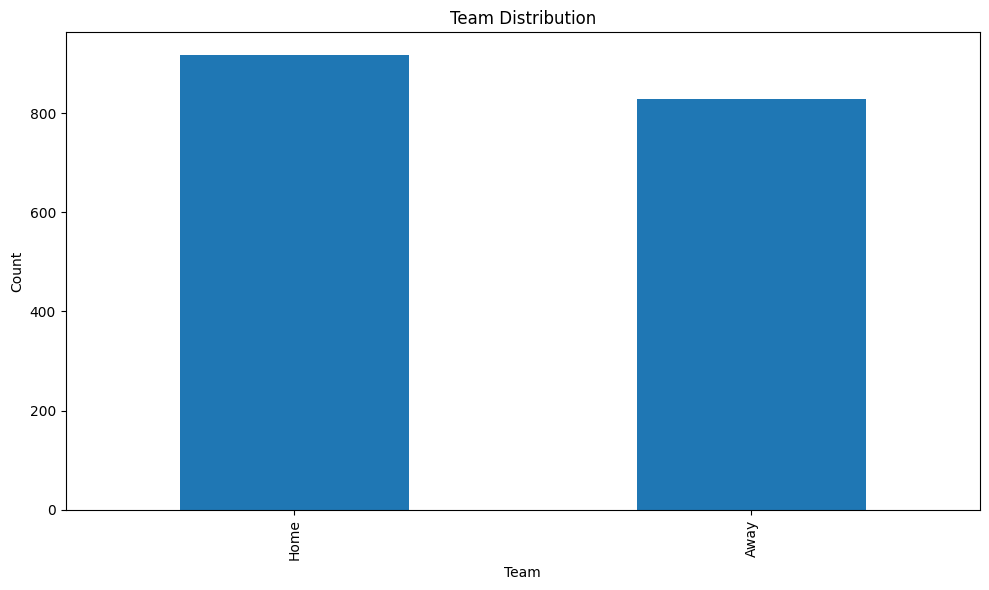

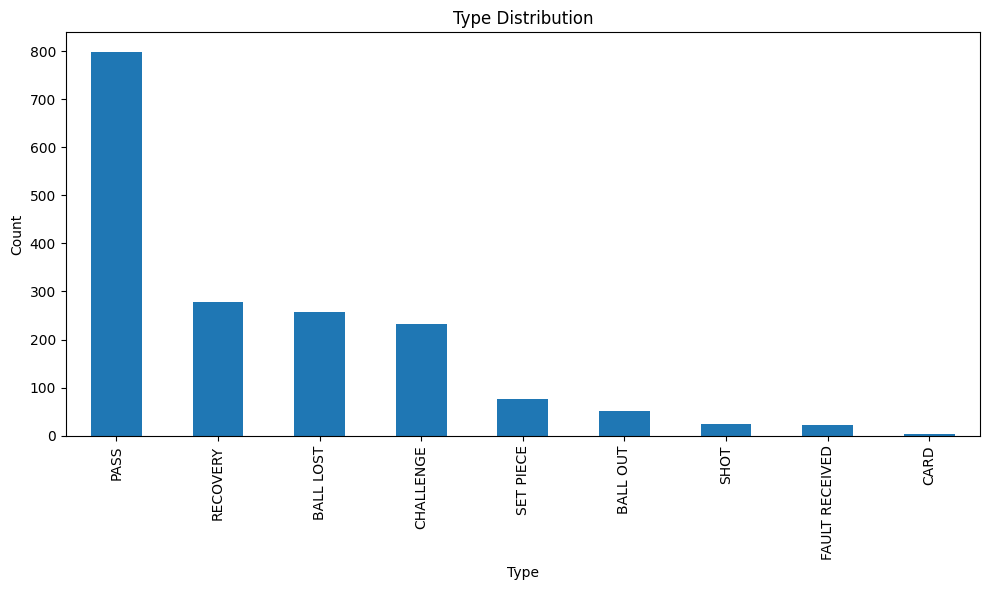

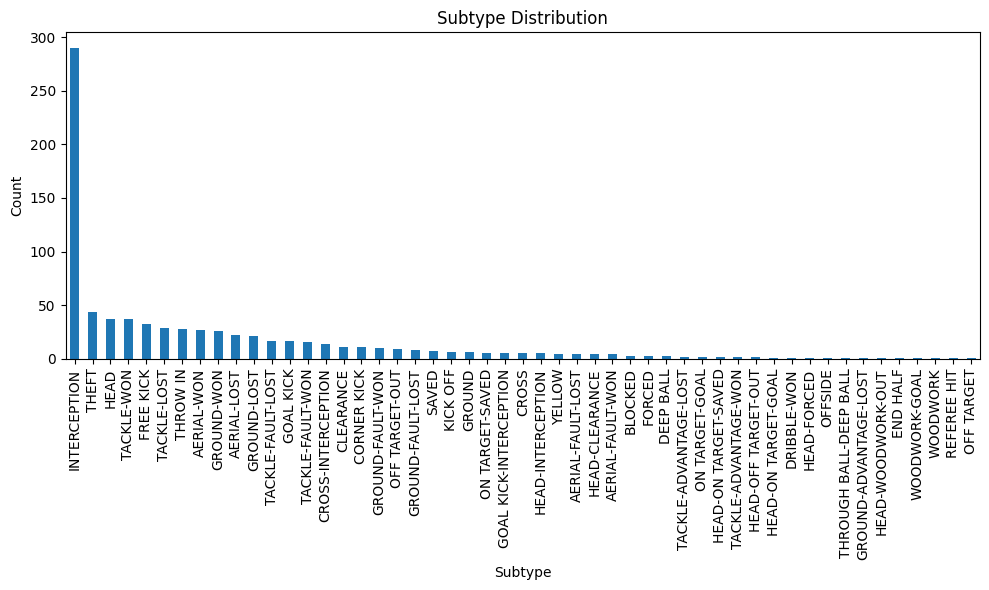

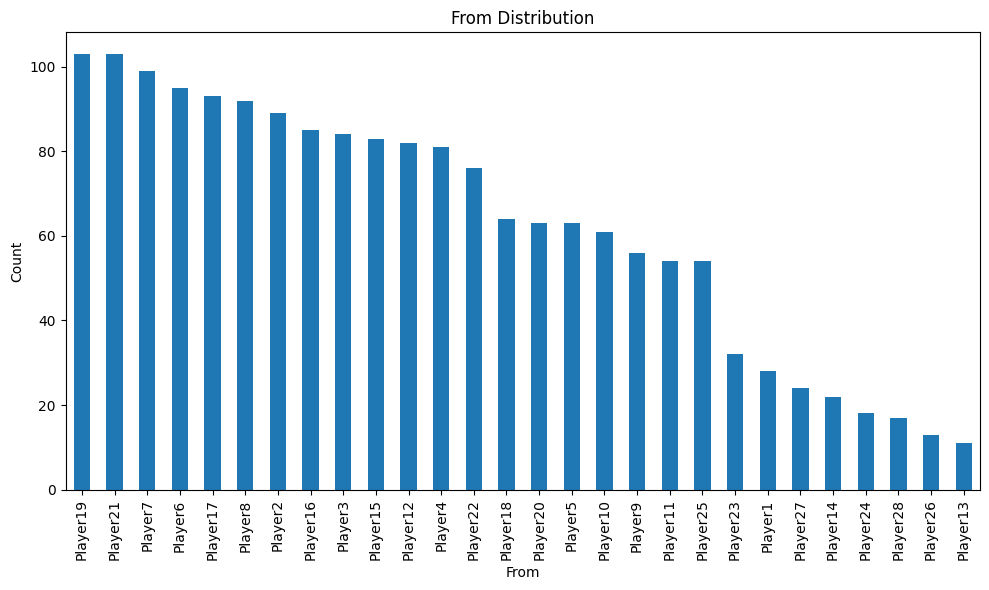

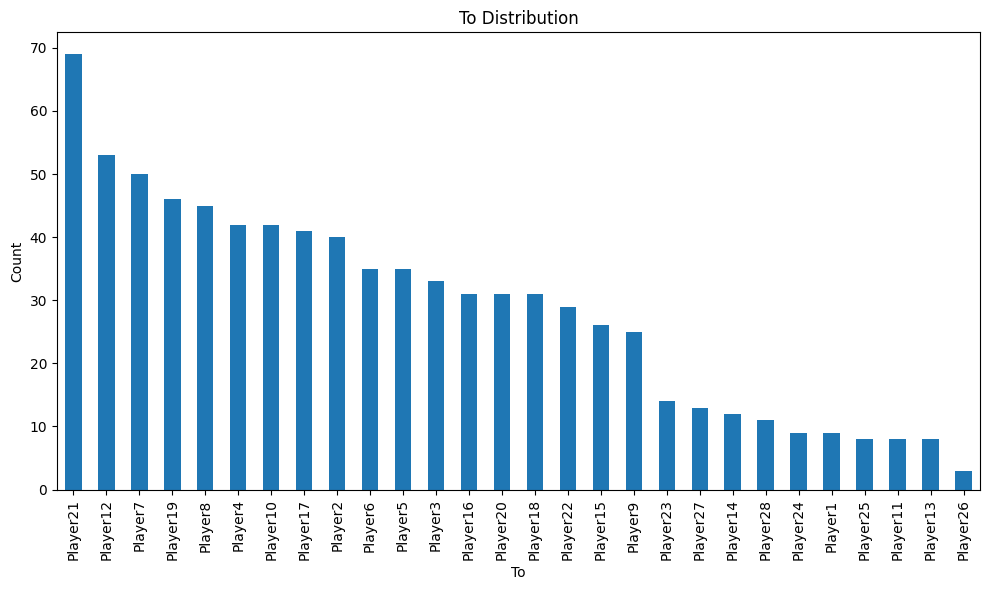

In [43]:
# Select categorical columns
cat_cols = events.select_dtypes(include=['object', 'category']).columns

n_cols = 2  
n_rows = int(np.ceil(len(cat_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = events[col].value_counts().sort_values(ascending=False)
    counts.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Remove unused subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# and one by one
for col in cat_cols:
    plt.figure(figsize=(10, 6))
    events[col].value_counts().sort_values(ascending=False).plot(kind='bar')
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

### 🏠 Team Distribution

- Roughly balanced Home vs Away  
- Good dataset balance for modeling  
- No major sampling bias  


### ⚽ Type Distribution

- PASS dominates heavily  
- Dataset is event-heavy on ball movement  
- Strong class imbalance (important for ML models)  


### 🔍 Subtype Distribution

- Very long tail distribution  
- Many rare event types  
- Likely need grouping or dimensionality reduction  
- Possible feature engineering opportunity  


### 👤 From Distribution

- Some players heavily involved  
- Identify key playmakers  
- Detect central players in the network  


### 🎯 To Distribution

- Passing targets distribution  
- Can build passing network graphs  
- Useful for tactical analysis  

### Data integrity / structural validation

In [44]:
home_players = set(events[events['Team'] == 'Home']['From'].unique())
away_players = set(events[events['Team'] == 'Away']['From'].unique())

# Check for players appearing in both teams (should be 0 if data is correct)
len(home_players.intersection(away_players))

0

No players overlap !

Check for Players Who Only Initiate

That would mean they initiate actions but never receive — which could indicate:

1)Data entry error

2)Missing rows

3)Filtering issues

4)Or just tactical reality (e.g., goalkeeper long balls)

In [45]:
from_players = set(events['From'].unique())
to_players = set(events['To'].unique())

only_initiators = from_players - to_players

only_initiators

set()

Same for only receivers

In [46]:
only_receivers = to_players - from_players

only_receivers

{nan}

### Missing Values

#### Check missing values for column To

Some events have:

To == NaN

That is completely normal in football event data for things like:

Shots

Clearances

Fouls

Ball out

Cards

Some duels

Those actions don't have a receiving player.

So this is not a structural network problem — it’s probably a data completeness issue but we should check this.

In [47]:
events[events['To'].isna()]['Type'].value_counts()

Type
RECOVERY          278
BALL LOST         257
CHALLENGE         233
SET PIECE          77
BALL OUT           51
SHOT               24
FAULT RECEIVED     22
CARD                4
Name: count, dtype: int64

#### We apply same logic for subtypes that also have missing values

In [48]:
events[events['Subtype'].isna()]['Type'].value_counts()

Type
PASS              757
RECOVERY           84
BALL LOST          51
BALL OUT           39
FAULT RECEIVED     22
Name: count, dtype: int64

#### Check PASS Subtype Coverage Rate

If ~90% are NaN → subtype probably not consistently recorded

If ~20% are NaN → maybe only special passes get subtypes

If ~100% are NaN → subtype field may be unused for passes

In [49]:
pass_events = events[events['Type'] == 'PASS']

pass_events['Subtype'].isna().mean() 

np.float64(0.9474342928660826)

In [50]:
pass_events['Subtype'].value_counts()

Subtype
HEAD                      20
GOAL KICK                 13
CROSS                      3
DEEP BALL                  2
HEAD-CLEARANCE             2
THROUGH BALL-DEEP BALL     1
CLEARANCE                  1
Name: count, dtype: int64

#### We should do this for all subtypes

In [51]:
events.groupby('Type')['Subtype'].apply(lambda x: x.isna().mean()).sort_values(ascending=False)

Type
FAULT RECEIVED    1.000000
PASS              0.947434
BALL OUT          0.764706
RECOVERY          0.302158
BALL LOST         0.198444
CHALLENGE         0.000000
CARD              0.000000
SET PIECE         0.000000
SHOT              0.000000
Name: Subtype, dtype: float64

3 groups appear:
1️⃣ Types where subtype is optional

PASS

BALL OUT

RECOVERY

BALL LOST

These are general events where subtype adds extra detail but is not required.

2️⃣ Types where subtype is mandatory

SHOT

SET PIECE

CARD

CHALLENGE

These events are defined by their subtype, so they always have one.

Example:

SHOT
 ├ HEAD
 ├ VOLLEY
 ├ FREE KICK

 
3️⃣ Types where subtype may not exist

FAULT RECEIVED

#### Create new subtype clean with filled subtypes

In [52]:
events['Subtype_clean'] = events['Subtype']

In [53]:
events.head()

,Team,Type,Subtype,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y,Subtype_clean
0,Away,SET PIECE,KICK OFF,1,1,0.04,0,0.00,Player19,NaN,NaN,NaN,NaN,NaN,KICK OFF
1,Away,PASS,NaN,1,1,0.04,3,0.12,Player19,Player21,0.45,0.39,0.55,0.43,NaN
2,Away,PASS,NaN,1,3,0.12,17,0.68,Player21,Player15,0.55,0.43,0.58,0.21,NaN
3,Away,PASS,NaN,1,45,1.80,61,2.44,Player15,Player19,0.55,0.19,0.45,0.31,NaN
4,Away,PASS,NaN,1,77,3.08,96,3.84,Player19,Player21,0.45,0.32,0.49,0.47,NaN


In [54]:
events.loc[
    (events['Type'] == 'PASS') & (events['Subtype_clean'].isna()),
    'Subtype_clean'
] = 'NORMAL PASS'

In [55]:
events.loc[
    (events['Subtype_clean'].isna()),
    'Subtype_clean'
] = events['Type']

#### Check again for missing in the new column

In [56]:
events.groupby('Type')['Subtype_clean'].apply(lambda x: x.isna().mean()).sort_values(ascending=False)

Type
BALL LOST         0.0
BALL OUT          0.0
CARD              0.0
CHALLENGE         0.0
FAULT RECEIVED    0.0
PASS              0.0
RECOVERY          0.0
SET PIECE         0.0
SHOT              0.0
Name: Subtype_clean, dtype: float64

In [57]:
# Drop old subtype column
events = events.drop(columns=['Subtype'])
events.head()

,Team,Type,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y,Subtype_clean
0,Away,SET PIECE,1,1,0.04,0,0.00,Player19,NaN,NaN,NaN,NaN,NaN,KICK OFF
1,Away,PASS,1,1,0.04,3,0.12,Player19,Player21,0.45,0.39,0.55,0.43,NORMAL PASS
2,Away,PASS,1,3,0.12,17,0.68,Player21,Player15,0.55,0.43,0.58,0.21,NORMAL PASS
3,Away,PASS,1,45,1.80,61,2.44,Player15,Player19,0.55,0.19,0.45,0.31,NORMAL PASS
4,Away,PASS,1,77,3.08,96,3.84,Player19,Player21,0.45,0.32,0.49,0.47,NORMAL PASS


## Measure Possesion [%]

In [58]:
possession_events = ['PASS', 'SHOT', 'BALL LOST', 'SET PIECE']

possession = (
    events[events['Type'].isin(possession_events)]
    ['Team']
    .value_counts(normalize=True)
    * 100
)

possession.round(2)

Team
Home    54.36
Away    45.64
Name: proportion, dtype: float64

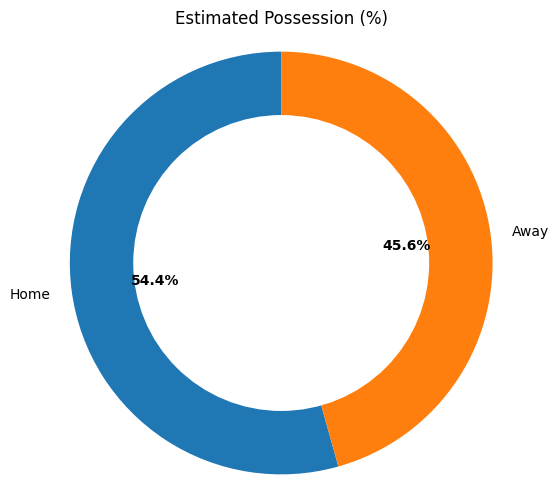

In [63]:

fig, ax = plt.subplots(figsize=(6, 6))

# Create the pie chart (donut base)
wedges, texts, autotexts = ax.pie(
    possession.round(2),
    labels=possession.index,           # Category labels
    autopct='%1.1f%%',            # Percentage format
    startangle=90,                # Start from top
    wedgeprops=dict(width=0.4),   # Width < 1 makes it a donut
    textprops=dict(color="black") # Label text color
)

# Customize label appearance
plt.setp(autotexts, size=10, weight="bold", color="black")
plt.setp(texts, size=10)

# Add a center circle for the donut hole
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Equal aspect ratio ensures the pie is drawn as a circle
ax.axis('equal')


plt.title('Estimated Possession (%)')



plt.show()

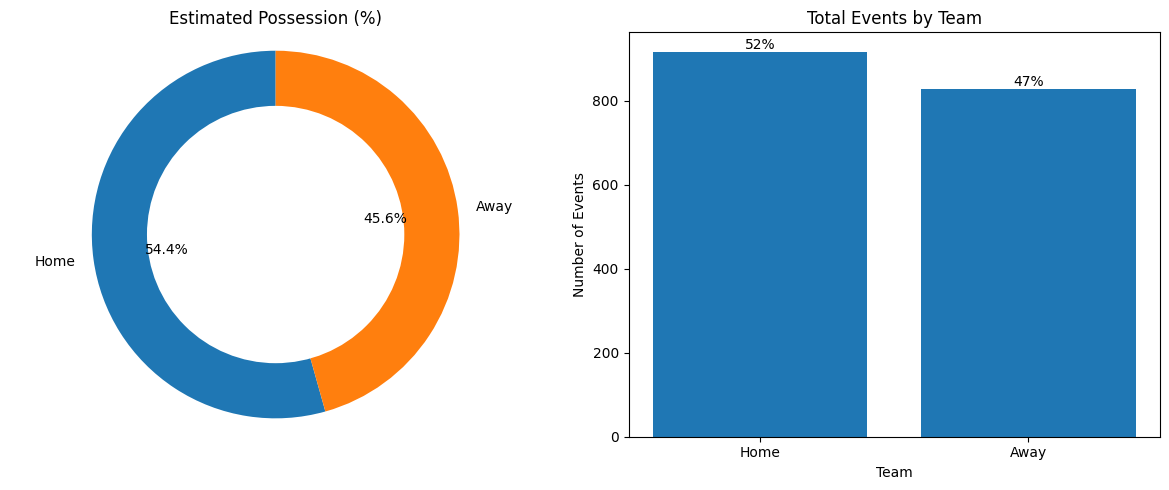

In [67]:
team_events = events['Team'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# --- Possession Donut ---
wedges, texts, autotexts = axes[0].pie(
    possession.round(2),
    labels=possession.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4)
)

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
axes[0].add_artist(centre_circle)

axes[0].set_title('Estimated Possession (%)')
axes[0].axis('equal')


# --- Total Events ---
bars = axes[1].bar(team_events.index, team_events.values)

axes[1].set_title('Total Events by Team')
axes[1].set_ylabel('Number of Events')
axes[1].set_xlabel('Team')

# Add data labels above bars
for bar in bars:
    height = bar.get_height()
    pct=(height / team_events.sum() * 100)
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(pct)}%',
        ha='center',
        va='bottom'
    )


plt.tight_layout()
plt.show()

There is a correlation between possesion and total events per team

#### Pass Completion [%]

Check if type PASS has To NaN

In [76]:
events[(events['Type'] == 'PASS') & (events['To'].isna())]

,Team,Type,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y,Subtype_clean


All passes are completed so we will check with other type

In [77]:
events['Type'].value_counts()

Type
PASS              799
RECOVERY          278
BALL LOST         257
CHALLENGE         233
SET PIECE          77
BALL OUT           51
SHOT               24
FAULT RECEIVED     22
CARD                4
Name: count, dtype: int64

We see that all the other Types are those that have NaN in To column but we cannot be sure if the ball is lost through pass.

We will instead find average passes per possession

In [83]:
possession_end = ['BALL LOST', 'BALL OUT', 'SHOT', 'FOUL RECEIVED', 'SET PIECE']

passes_per_possession = []

current_passes = 0

for _, row in events.iterrows():

    if row['Type'] == 'PASS':
        current_passes += 1

    if row['Type'] in possession_end:
        passes_per_possession.append(current_passes)
        current_passes = 0

In [84]:
team_passes = {'Home': [], 'Away': []}

current_passes = 0
current_team = None

for _, row in events.iterrows():

    if row['Type'] == 'PASS':
        current_passes += 1
        current_team = row['Team']

    if row['Type'] in possession_end and current_team is not None:
        team_passes[current_team].append(current_passes)
        current_passes = 0
        current_team = None

In [85]:
avg_passes_team = {
    team: np.mean(vals) for team, vals in team_passes.items()
}

avg_passes_team

{'Home': np.float64(3.8035714285714284), 'Away': np.float64(3.73)}

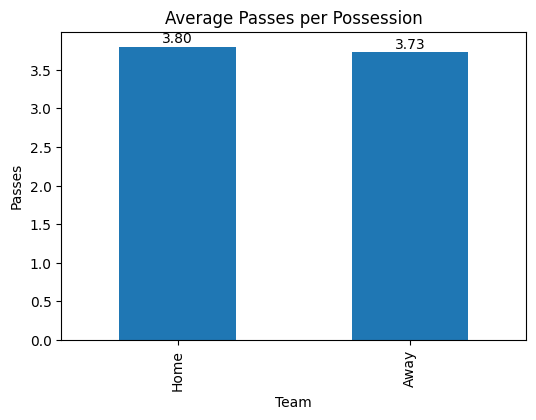

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

pd.Series(avg_passes_team).plot(kind='bar', figsize=(6,4))

plt.title('Average Passes per Possession')
plt.ylabel('Passes')
plt.xlabel('Team')

for i, v in enumerate(avg_passes_team.values()):
    plt.text(i, v + 0.05, f"{v:.2f}", ha='center')

plt.show()

The two teams are pretty similar in build up and possession

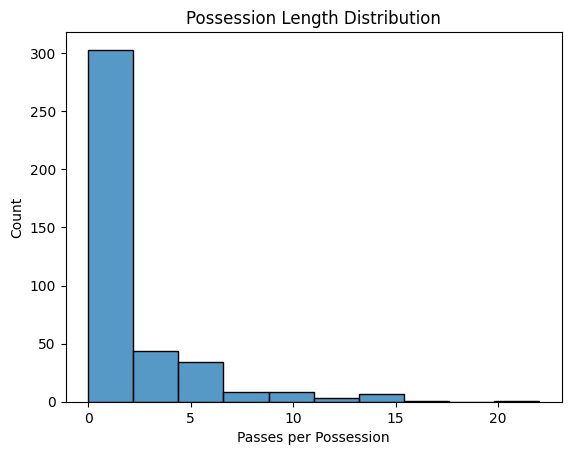

In [87]:
import seaborn as sns

sns.histplot(passes_per_possession, bins=10)

plt.title('Possession Length Distribution')
plt.xlabel('Passes per Possession')
plt.ylabel('Count')

plt.show()

#### Passing Network Graph (players + passes)

##### Counts passes per pair

In [90]:
pass_pairs = pass_events.groupby(['From','To', 'Team']).size().reset_index(name='count')
pass_pairs.sort_values('count', ascending=False).head(10)

,From,To,Team,count
86,Player19,Player21,Away,13
177,Player4,Player8,Home,13
204,Player7,Player2,Home,13
100,Player2,Player7,Home,12
117,Player21,Player19,Away,11
163,Player3,Player2,Home,11
186,Player5,Player7,Home,11
190,Player6,Player10,Home,10
115,Player21,Player17,Away,10
215,Player8,Player4,Home,10


In [92]:
import networkx as nx

G = nx.DiGraph()

for _, row in pass_pairs.iterrows():
    G.add_edge(row['From'], row['To'], weight=row['count'])

In [93]:
pos = nx.spring_layout(G, seed=42)

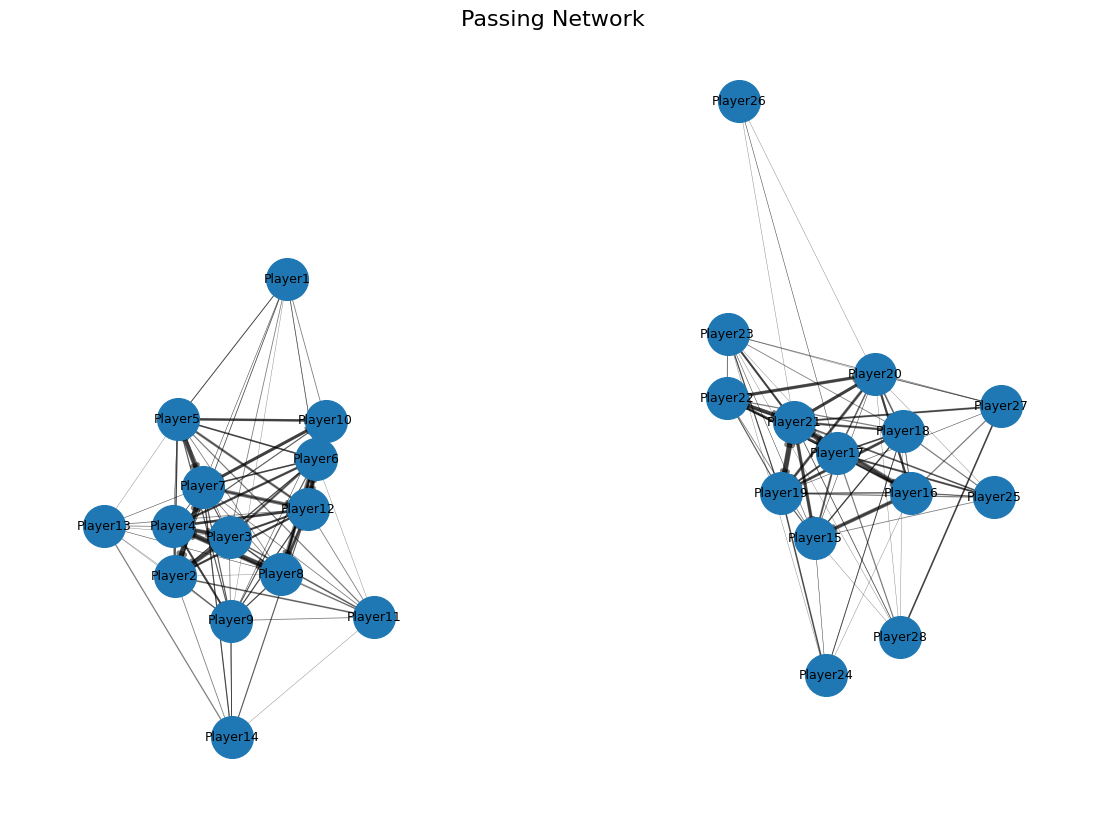

In [96]:
plt.figure(figsize=(14,10))

pos = nx.spring_layout(G, k=1.2, seed=42)

edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]

nx.draw_networkx_nodes(G, pos, node_size=900)

nx.draw_networkx_labels(G, pos, font_size=9)

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=edges,
    width=[w*0.3 for w in weights],
    alpha=0.5
)

plt.title("Passing Network", fontsize=16)
plt.axis('off')

plt.show()

In [97]:
passes_home = events[(events['Type'] == 'PASS') & (events['Team'] == 'Home')]

In [98]:
player_pos = passes_home.groupby('From')[['Start X','Start Y']].mean()

In [99]:
pass_pairs = passes_home.groupby(['From','To']).size().reset_index(name='count')

(np.float64(0.0), np.float64(100.0), np.float64(0.0), np.float64(100.0))

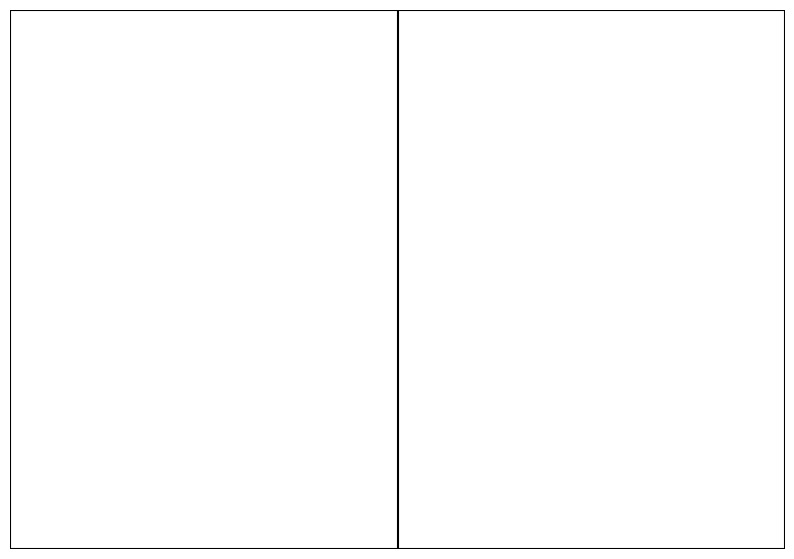

In [ ]:

ax.set_ylim(0,100)

ax.axis('off')